<a href="https://colab.research.google.com/github/khushihirawat/post-disaster-assessment/blob/main/CVDL_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CVDL RESEARCH PROJECT (DISASTER DAMAGE ANALYSIS)


In [1]:
#!pip install tensorflow keras matplotlib scikit-learn seaborn -q

import random
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, f1_score)

print("GPU Available:", tf.config.list_physical_devices('GPU'))
print("TensorFlow:", tf.__version__)

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TensorFlow: 2.20.0


In [2]:
import kagglehub
path = kagglehub.dataset_download("kmader/satellite-images-of-hurricane-damage")

print("Path to dataset files:", path)

100%|██████████| 63.0M/63.0M [00:00<00:00, 80.4MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/kmader/satellite-images-of-hurricane-damage/versions/1


In [3]:
DATASET_ROOT = Path(path)

print("\nFull folder structure:")
for item in sorted(DATASET_ROOT.rglob('*')):
    if item.is_dir():
        images = list(item.glob('*.jpg')) + \
                 list(item.glob('*.png')) + \
                 list(item.glob('*.jpeg'))
        print(f"  {item.relative_to(DATASET_ROOT)}/ — {len(images)} images")


Full folder structure:
  test/ — 0 images
  test/damage/ — 1000 images
  test/no_damage/ — 1000 images
  test_another/ — 0 images
  test_another/damage/ — 8000 images
  test_another/no_damage/ — 1000 images
  train_another/ — 0 images
  train_another/damage/ — 5000 images
  train_another/no_damage/ — 5000 images
  validation_another/ — 0 images
  validation_another/damage/ — 1000 images
  validation_another/no_damage/ — 1000 images


In [4]:
IMAGE_SIZE  = (128, 128)
BATCH_SIZE  = 64
EPOCHS_P1   = 5
EPOCHS_P2   = 10
LR_P1       = 1e-4
LR_P2       = 1e-5
SEED        = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

DATASET_ROOT = Path(path)
TRAIN_DIR    = DATASET_ROOT / 'train_another'
VAL_DIR      = DATASET_ROOT / 'validation_another'
TEST_DIR     = DATASET_ROOT / 'test'
TEST_IMB_DIR = DATASET_ROOT / 'test_another'

print(f"Train : {TRAIN_DIR}")
print(f"Val   : {VAL_DIR}")
print(f"Test  : {TEST_DIR}")


Train : /root/.cache/kagglehub/datasets/kmader/satellite-images-of-hurricane-damage/versions/1/train_another
Val   : /root/.cache/kagglehub/datasets/kmader/satellite-images-of-hurricane-damage/versions/1/validation_another
Test  : /root/.cache/kagglehub/datasets/kmader/satellite-images-of-hurricane-damage/versions/1/test


SAMPLE DATA IMAGES

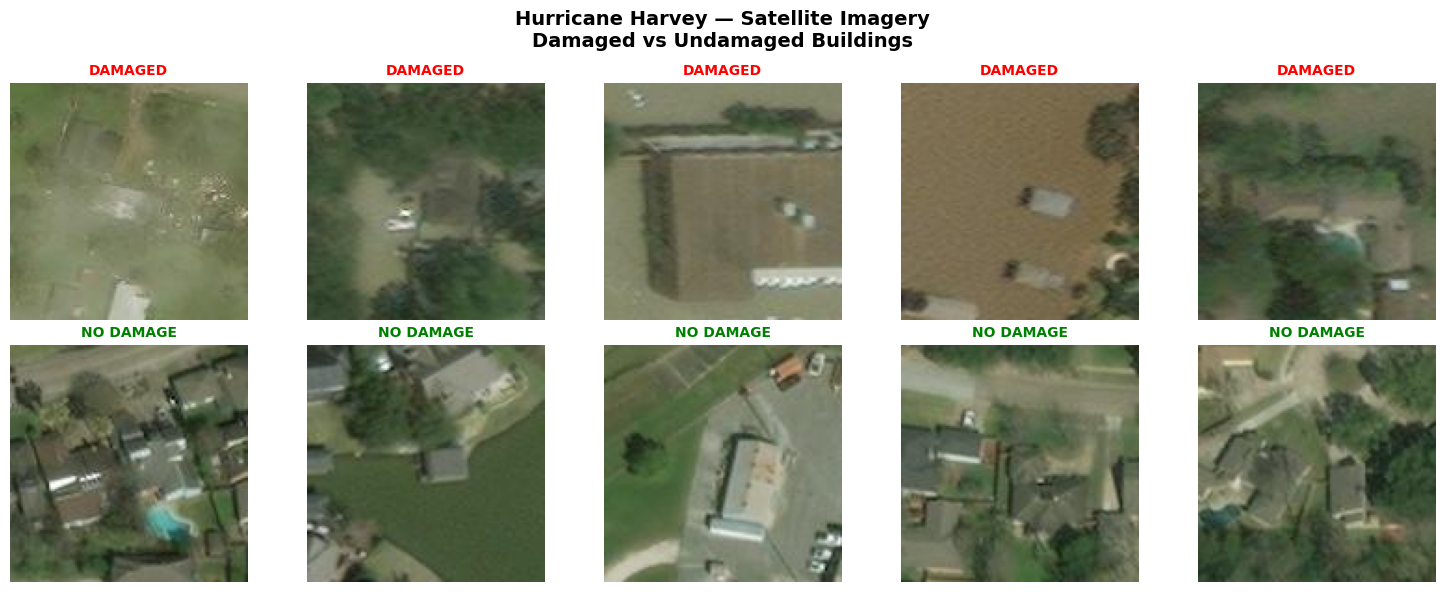

Figure 1 saved


In [5]:
def show_samples(train_dir: Path, n: int = 5):
    damage_dir    = train_dir / 'damage'
    no_damage_dir = train_dir / 'no_damage'

    damage_imgs    = random.sample(list(damage_dir.iterdir()), n)
    no_damage_imgs = random.sample(list(no_damage_dir.iterdir()), n)

    fig, axes = plt.subplots(2, n, figsize=(15, 6))
    fig.suptitle('Hurricane Harvey — Satellite Imagery\nDamaged vs Undamaged Buildings',
                 fontsize=14, fontweight='bold')

    for i in range(n):
        img = Image.open(damage_imgs[i])
        axes[0, i].imshow(img)
        axes[0, i].set_title('DAMAGED', color='red', fontweight='bold', fontsize=10)
        axes[0, i].axis('off')

        img = Image.open(no_damage_imgs[i])
        axes[1, i].imshow(img)
        axes[1, i].set_title('NO DAMAGE', color='green', fontweight='bold', fontsize=10)
        axes[1, i].axis('off')

    plt.tight_layout()
    plt.savefig('figure1_dataset_samples.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Figure 1 saved")

show_samples(TRAIN_DIR)

CBAM

In [6]:
def channel_attention(input_feature, ratio=8):
    """
    Channel Attention Module.
    Asks: which of the 1280 feature channels are most important?

    Steps:
    1. Apply both AvgPool and MaxPool across the spatial dimensions (4x4 → 1x1)
    2. Pass both through a shared 2-layer MLP
    3. Add results and apply sigmoid to get channel weights (0-1)
    4. Multiply original features by these weights

    ratio=8 means the MLP bottleneck has 1280/8 = 160 units.
    """
    channel = input_feature.shape[-1]   # 1280 for EfficientNetB0

    # shared MLP layers
    shared_dense_1 = layers.Dense(channel // ratio, activation='relu',
                                   use_bias=False)
    shared_dense_2 = layers.Dense(channel, use_bias=False)

    # average pool path
    avg_pool = layers.GlobalAveragePooling2D()(input_feature)
    avg_pool = layers.Reshape((1, 1, channel))(avg_pool)
    avg_pool = shared_dense_1(avg_pool)
    avg_pool = shared_dense_2(avg_pool)

    # max pool path
    max_pool = layers.GlobalMaxPooling2D()(input_feature)
    max_pool = layers.Reshape((1, 1, channel))(max_pool)
    max_pool = shared_dense_1(max_pool)
    max_pool = shared_dense_2(max_pool)

    # combine and apply sigmoid
    attention = layers.Add()([avg_pool, max_pool])
    attention = layers.Activation('sigmoid')(attention)

    # rescale input features by channel weights
    return layers.Multiply()([input_feature, attention])


def spatial_attention(input_feature, kernel_size=7):
    """
    Spatial Attention Module.
    Asks: which spatial locations (pixels) in the feature map matter most?

    Steps:
    1. Compute channel-wise AvgPool and MaxPool across 1280 channels → 2 maps
    2. Concatenate → (4, 4, 2)
    3. Apply 7x7 Conv → (4, 4, 1) attention map
    4. Apply sigmoid → spatial weights
    5. Multiply original features by spatial weights

    A 7x7 kernel captures wider spatial context than 3x3.
    """
    # channel-wise statistics
    avg_pool = tf.reduce_mean(input_feature, axis=-1, keepdims=True)  # (4,4,1)
    max_pool = tf.reduce_max(input_feature,  axis=-1, keepdims=True)  # (4,4,1)

    # concatenate along channel axis → (4,4,2)
    concat = layers.Concatenate(axis=-1)([avg_pool, max_pool])

    # 7x7 convolution to learn spatial importance
    attention = layers.Conv2D(1, kernel_size=kernel_size,
                               padding='same',
                               activation='sigmoid',
                               use_bias=False)(concat)   # (4,4,1)

    # rescale input features by spatial weights
    return layers.Multiply()([input_feature, attention])


def cbam_block(input_feature, ratio=8, kernel_size=7):
    """
    Full CBAM Block: Channel Attention → Spatial Attention (sequential).

    Applied on top of the EfficientNetB0 feature maps (4×4×1280).
    Forces the model to focus on which features AND where in the image.
    """
    x = channel_attention(input_feature, ratio)
    x = spatial_attention(x, kernel_size)
    return x


print("CBAM module defined successfully")
print("Channel Attention: rescales 1280 feature channels by learned importance")
print("Spatial Attention: rescales 4x4 spatial locations by learned importance")

CBAM module defined successfully
Channel Attention: rescales 1280 feature channels by learned importance
Spatial Attention: rescales 4x4 spatial locations by learned importance


DATA PIPELINE

In [7]:
# Updated augmentation — ±20° rotation as per new pipeline
train_datagen = ImageDataGenerator(
    horizontal_flip    = True,
    vertical_flip      = True,
    rotation_range     = 20,          # changed from 90 to 20 per panel suggestion
    zoom_range         = 0.1,
    width_shift_range  = 0.1,
    height_shift_range = 0.1,
    brightness_range   = [0.8, 1.2],
    validation_split   = 0.0          # not using split — using separate val_dir
)

val_test_datagen = ImageDataGenerator()

train_generator = train_datagen.flow_from_directory(
    str(TRAIN_DIR),
    target_size = IMAGE_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = 'binary',
    seed        = SEED,
    shuffle     = True
)

val_generator = val_test_datagen.flow_from_directory(
    str(VAL_DIR),
    target_size = IMAGE_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = 'binary',
    shuffle     = False
)

print(f"Class mapping : {train_generator.class_indices}")
print(f"Train samples : {train_generator.samples}")
print(f"Val samples   : {val_generator.samples}")

Found 10000 images belonging to 2 classes.
Found 2000 images belonging to 2 classes.
Class mapping : {'damage': 0, 'no_damage': 1}
Train samples : 10000
Val samples   : 2000


BUILDING MODEL WITH CBAM

In [10]:
def channel_attention(input_feature, ratio=8):
    """
    Channel Attention Module.
    Asks: which of the 1280 feature channels are most important?
    Uses both AvgPool and MaxPool paths through a shared MLP,
    combines them and applies sigmoid to get per-channel weights.
    """
    channel = input_feature.shape[-1]

    # shared MLP — same weights used for both paths
    shared_dense_1 = layers.Dense(channel // ratio,
                                   activation='relu',
                                   use_bias=False)
    shared_dense_2 = layers.Dense(channel, use_bias=False)

    # average pool path: (H,W,C) → (1,1,C)
    avg_pool = layers.GlobalAveragePooling2D()(input_feature)
    avg_pool = layers.Reshape((1, 1, channel))(avg_pool)
    avg_pool = shared_dense_1(avg_pool)
    avg_pool = shared_dense_2(avg_pool)

    # max pool path: (H,W,C) → (1,1,C)
    max_pool = layers.GlobalMaxPooling2D()(input_feature)
    max_pool = layers.Reshape((1, 1, channel))(max_pool)
    max_pool = shared_dense_1(max_pool)
    max_pool = shared_dense_2(max_pool)

    # add paths and apply sigmoid → channel weights between 0 and 1
    attention = layers.Add()([avg_pool, max_pool])
    attention = layers.Activation('sigmoid')(attention)

    # rescale input channels by learned weights
    return layers.Multiply()([input_feature, attention])


def spatial_attention(input_feature, kernel_size=7):
    """
    Spatial Attention Module.
    Asks: which spatial locations in the 4x4 feature map matter most?

    FIX: replaced tf.reduce_mean and tf.reduce_max (raw TF ops that
    break Keras functional API) with keras.ops.mean and keras.ops.max
    which are KerasTensor-compatible.
    """

    # channel-wise average across 1280 channels → (4, 4, 1)
    # keras.ops.mean is the Keras-native equivalent of tf.reduce_mean
    avg_pool = keras.ops.mean(input_feature, axis=-1, keepdims=True)

    # channel-wise max across 1280 channels → (4, 4, 1)
    # keras.ops.max is the Keras-native equivalent of tf.reduce_max
    max_pool = keras.ops.max(input_feature,  axis=-1, keepdims=True)

    # concatenate along last axis → (4, 4, 2)
    concat = layers.Concatenate(axis=-1)([avg_pool, max_pool])

    # 7x7 conv learns which spatial locations matter → (4, 4, 1)
    attention = layers.Conv2D(
        filters     = 1,
        kernel_size = kernel_size,
        padding     = 'same',
        activation  = 'sigmoid',
        use_bias    = False
    )(concat)

    # rescale input feature map by spatial weights
    return layers.Multiply()([input_feature, attention])


def cbam_block(input_feature, ratio=8, kernel_size=7):
    """
    Full CBAM: Channel Attention first, then Spatial Attention.
    Both operate on the EfficientNetB0 feature maps (4×4×1280).
    """
    x = channel_attention(input_feature, ratio)
    x = spatial_attention(x, kernel_size)
    return x


print("CBAM module defined — using keras.ops (KerasTensor-compatible)")
print("Channel Attention : rescales 1280 feature channels by importance")
print("Spatial Attention : rescales 4×4 spatial locations by importance")

CBAM module defined — using keras.ops (KerasTensor-compatible)
Channel Attention : rescales 1280 feature channels by importance
Spatial Attention : rescales 4×4 spatial locations by importance


In [13]:
# ── Step 1: Clear any previous session ────────────────────────
keras.backend.clear_session()
print("Session cleared")

# ── Step 2: Verify CBAM works before building full model ──────
test_input = keras.Input(shape=(4, 4, 32))
test_out   = cbam_block(test_input, ratio=4, kernel_size=3)
test_model = keras.Model(test_input, test_out)
print(f"CBAM sanity check passed — output shape: {test_model.output_shape}")
del test_model  # clean up test model

# ── Step 3: Load backbone ──────────────────────────────────────
base_model = EfficientNetB0(
    weights     = 'imagenet',
    include_top = False,
    input_shape = (128, 128, 3)
)
base_model.trainable = False
print(f"EfficientNetB0 loaded — frozen layers: {len(base_model.layers)}")

# ── Step 4: Build full model ───────────────────────────────────
inputs = keras.Input(shape=(128, 128, 3))

x = keras.applications.efficientnet.preprocess_input(inputs)
x = base_model(x, training=False)

print(f"Backbone output shape: {x.shape}")  # should be (None, 4, 4, 1280)

# CBAM attention
x = cbam_block(x, ratio=8, kernel_size=7)
print(f"After CBAM shape    : {x.shape}")   # should still be (None, 4, 4, 1280)

# classification head
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dense(256, activation='gelu')(x)
x       = layers.Dropout(0.4)(x)
x       = layers.Dense(64,  activation='gelu')(x)
outputs = layers.Dense(1,   activation='sigmoid')(x)

model = keras.Model(inputs, outputs)

# ── Step 5: Compile ────────────────────────────────────────────
model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=LR_P1),
    loss      = 'binary_crossentropy',
    metrics   = [
        'accuracy',
        keras.metrics.AUC(name='auc'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall')
    ]
)

# ── Step 6: Confirm everything is ready ───────────────────────
print("\n" + "=" * 65)
print("MODEL BUILT SUCCESSFULLY")
print("=" * 65)
print(f"Total parameters     : {model.count_params():,}")
print(f"Input shape          : {model.input_shape}")
print(f"Output shape         : {model.output_shape}")
print("\nReady to train — run Block 7 (Phase 1)")

Session cleared
CBAM sanity check passed — output shape: (None, 4, 4, 32)
EfficientNetB0 loaded — frozen layers: 238
Backbone output shape: (None, 4, 4, 1280)
After CBAM shape    : (None, 4, 4, 1280)

MODEL BUILT SUCCESSFULLY
Total parameters     : 4,808,838
Input shape          : (None, 128, 128, 3)
Output shape         : (None, 1)

Ready to train — run Block 7 (Phase 1)


CALLBACKS

In [14]:
callbacks = [
    ModelCheckpoint(
        filepath       = 'best_cbam_model.keras',
        monitor        = 'val_auc',
        save_best_only = True,
        mode           = 'max',
        verbose        = 1
    ),
    EarlyStopping(
        monitor              = 'val_auc',
        patience             = 5,
        restore_best_weights = True,
        verbose              = 1
    ),
    ReduceLROnPlateau(
        monitor  = 'val_loss',
        factor   = 0.5,
        patience = 3,
        min_lr   = 1e-7,
        verbose  = 1
    )
]
print("Callbacks ready")

Callbacks ready


PHASE 1 TRAIN

In [ ]:
print("=" * 65)
print("PHASE 1 — Head + CBAM only | Backbone FROZEN")
print("=" * 65)

history_p1 = model.fit(
    train_generator,
    epochs          = EPOCHS_P1,
    validation_data = val_generator,
    callbacks       = callbacks,
    verbose         = 1
)

p1_best_acc = max(history_p1.history['val_accuracy'])
p1_best_auc = max(history_p1.history['val_auc'])
print(f"\nPhase 1 complete")
print(f"Best Val Accuracy : {p1_best_acc*100:.2f}%")
print(f"Best Val AUC      : {p1_best_auc:.4f}")

PHASE 1 — Head + CBAM only | Backbone FROZEN
Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 670ms/step - accuracy: 0.6967 - auc: 0.7637 - loss: 0.5866 - precision: 0.6706 - recall: 0.8007
Epoch 1: val_auc improved from None to 0.93211, saving model to best_cbam_model.keras

Epoch 1: finished saving model to best_cbam_model.keras
157/157 ━━━━━━━━━━━━━━━━━━━━ 162s 786ms/step - accuracy: 0.7676 - auc: 0.8505 - loss: 0.4822 - precision: 0.7457 - recall: 0.8122 - val_accuracy: 0.8535 - val_auc: 0.9321 - val_loss: 0.5114 - val_precision: 0.8855 - val_recall: 0.8120 - learning_rate: 1.0000e-04
Epoch 2/5
 14/157 ━━━━━━━━━━━━━━━━━━━━ 53s 373ms/step - accuracy: 0.8595 - auc: 0.9338 - loss: 0.3331 - precision: 0.8673 - recall: 0.8602

PHASE 2 FINE TUNE

In [ ]:
print("=" * 65)
print("PHASE 2 — Fine-tuning top 30 EfficientNet layers")
print("=" * 65)

# reload best phase 1 model
model = keras.models.load_model(
    'best_cbam_model.keras',
    custom_objects={
        'channel_attention': channel_attention,
        'spatial_attention': spatial_attention,
        'cbam_block': cbam_block
    }
)

# unfreeze backbone and re-freeze lower layers
efficientnet_layer = None
for layer in model.layers:
    if 'efficientnetb0' in layer.name.lower():
        efficientnet_layer = layer
        break

efficientnet_layer.trainable = True
for layer in efficientnet_layer.layers[:-30]:
    layer.trainable = False

trainable = sum(1 for l in efficientnet_layer.layers if l.trainable)
frozen    = sum(1 for l in efficientnet_layer.layers if not l.trainable)
print(f"EfficientNet trainable layers : {trainable}")
print(f"EfficientNet frozen layers    : {frozen}")

model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=LR_P2),
    loss      = 'binary_crossentropy',
    metrics   = [
        'accuracy',
        keras.metrics.AUC(name='auc'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall')
    ]
)

callbacks_p2 = [
    ModelCheckpoint(
        filepath       = 'best_cbam_model_p2.keras',
        monitor        = 'val_auc',
        save_best_only = True,
        mode           = 'max',
        verbose        = 1
    ),
    EarlyStopping(
        monitor              = 'val_auc',
        patience             = 5,
        restore_best_weights = True,
        verbose              = 1
    ),
    ReduceLROnPlateau(
        monitor  = 'val_loss',
        factor   = 0.5,
        patience = 3,
        min_lr   = 1e-7,
        verbose  = 1
    )
]

history_p2 = model.fit(
    train_generator,
    epochs          = EPOCHS_P2,
    validation_data = val_generator,
    callbacks       = callbacks_p2,
    verbose         = 1
)

p2_best_acc = max(history_p2.history['val_accuracy'])
p2_best_auc = max(history_p2.history['val_auc'])
print(f"\nPhase 2 complete")
print(f"Best Val Accuracy : {p2_best_acc*100:.2f}%")
print(f"Best Val AUC      : {p2_best_auc:.4f}")

ALBATION STUDY

SCORE CAM

In [ ]:
print("=" * 65)
print("SCORE-CAM EXPLAINABILITY")
print("Gradient-free alternative to Grad-CAM")
print("=" * 65)

def score_cam(model, img_array, layer_name=None):
    """
    Score-CAM: gradient-free class activation mapping.

    How it works:
    1. Get all activation maps from the last conv layer
    2. Upsample each map to input size
    3. Normalise each map to [0,1] and use as a mask
    4. Pass masked image through model — get confidence score
    5. Weight each activation map by its confidence score
    6. Sum weighted maps → final Score-CAM heatmap

    Advantage over Grad-CAM: no gradient computation needed,
    more stable and less noisy for small feature maps like 4×4.
    """
    # find last conv layer inside EfficientNetB0
    efficientnet = None
    for layer in model.layers:
        if 'efficientnetb0' in layer.name.lower():
            efficientnet = layer
            break

    last_conv = None
    for layer in reversed(efficientnet.layers):
        if isinstance(layer, keras.layers.Conv2D):
            last_conv = layer
            break

    print(f"Using layer: {last_conv.name}")

    # model to extract conv activations
    activation_model = keras.Model(
        inputs  = efficientnet.input,
        outputs = last_conv.output
    )

    # get activation maps for this image — shape (1, 4, 4, 1280)
    activations = activation_model.predict(img_array, verbose=0)
    activations = activations[0]   # (4, 4, 1280)
    n_channels  = activations.shape[-1]

    scores = []
    for i in range(n_channels):
        # upsample single channel map to input size
        act_map = activations[:, :, i]
        act_min, act_max = act_map.min(), act_map.max()
        if act_max - act_min < 1e-8:
            scores.append(0.0)
            continue

        # normalise to [0,1]
        act_norm = (act_map - act_min) / (act_max - act_min)

        # upsample to 128×128
        act_upsampled = np.array(
            Image.fromarray(act_norm).resize(IMAGE_SIZE, Image.LANCZOS)
        )

        # use as soft mask on original image
        masked_img = img_array[0] * act_upsampled[:, :, np.newaxis]
        masked_img = np.expand_dims(masked_img, axis=0)

        # get model confidence on masked image
        score = model.predict(masked_img, verbose=0)[0][0]
        scores.append(float(score))

    scores = np.array(scores)

    # weight activations by confidence scores
    cam = np.zeros((4, 4))
    for i in range(n_channels):
        cam += scores[i] * activations[:, :, i]

    # relu and normalise
    cam = np.maximum(cam, 0)
    if cam.max() > 0:
        cam = cam / cam.max()

    return cam


def visualise_score_cam(model, img_path, alpha=0.45):
    img     = Image.open(img_path).resize(IMAGE_SIZE).convert('RGB')
    img_np  = np.array(img, dtype='float32')
    img_in  = np.expand_dims(img_np, axis=0)

    cam     = score_cam(model, img_in)

    # upsample cam to 128×128
    cam_img = Image.fromarray(np.uint8(255 * cam)).resize(IMAGE_SIZE, Image.LANCZOS)
    cam_rgb = plt.cm.jet(np.array(cam_img) / 255.0)[:, :, :3]
    cam_rgb = np.uint8(cam_rgb * 255)
    overlay = np.uint8(img_np * (1 - alpha) + cam_rgb * alpha)

    pred    = model.predict(img_in, verbose=0)[0][0]
    label   = "DAMAGED" if pred > 0.5 else "NO DAMAGE"
    conf    = pred if pred > 0.5 else 1 - pred

    return np.array(img), overlay, label, conf


# generate Score-CAM for 3 damaged + 3 undamaged
model = keras.models.load_model('best_cbam_model_p2.keras',
                                 custom_objects={
                                     'channel_attention': channel_attention,
                                     'spatial_attention': spatial_attention,
                                     'cbam_block': cbam_block
                                 })

damage_samples    = random.sample(list((TEST_DIR / 'damage').iterdir()), 3)
no_damage_samples = random.sample(list((TEST_DIR / 'no_damage').iterdir()), 3)
all_samples       = (
    [(p, 'DAMAGED',   '#E24B4A') for p in damage_samples] +
    [(p, 'NO DAMAGE', '#1D9E75') for p in no_damage_samples]
)

fig, axes = plt.subplots(6, 2, figsize=(10, 18))
fig.suptitle('Score-CAM Explainability — Gradient-Free Visualisation\n'
             'Red = high attention | Blue = low attention',
             fontsize=13, fontweight='bold')

for i, (img_path, true_label, colour) in enumerate(all_samples):
    original, overlay, pred_label, conf = visualise_score_cam(model, img_path)
    correct    = pred_label == true_label
    res_colour = '#1D9E75' if correct else '#E24B4A'

    axes[i, 0].imshow(original)
    axes[i, 0].set_title(f'True: {true_label}', color=colour,
                          fontweight='bold', fontsize=10)
    axes[i, 0].axis('off')

    axes[i, 1].imshow(overlay)
    axes[i, 1].set_title(
        f'Pred: {pred_label} ({conf*100:.1f}%)\n'
        f'{"✓ Correct" if correct else "✗ Wrong"}',
        color=res_colour, fontweight='bold', fontsize=10
    )
    axes[i, 1].axis('off')

plt.tight_layout()
plt.savefig('figure_score_cam.png', dpi=150, bbox_inches='tight')
plt.show()
print("Score-CAM figure saved")

INFERENCE TIME MEASUREMENT

In [ ]:
print("=" * 65)
print("COMPUTATIONAL ANALYSIS — Inference Time")
print("=" * 65)

# warm up the model first (first prediction is always slower)
dummy = np.random.rand(1, 128, 128, 3).astype('float32')
_ = model.predict(dummy, verbose=0)

# single image inference
n_trials = 100
times = []
for _ in range(n_trials):
    start = time.time()
    _ = model.predict(dummy, verbose=0)
    times.append(time.time() - start)

avg_time_ms = np.mean(times) * 1000
std_time_ms = np.std(times)  * 1000

print(f"Single image inference time : {avg_time_ms:.2f} ± {std_time_ms:.2f} ms")
print(f"Images per second           : {1000/avg_time_ms:.1f}")
print(f"23,000 images would take    : {23000 * avg_time_ms / 1000 / 60:.1f} minutes")
print(f"Total parameters            : {model.count_params():,}")

COMPLETE EVALUATION

In [ ]:
print("=" * 65)
print("FULL EVALUATION — Balanced Test Set")
print("=" * 65)

test_datagen = ImageDataGenerator()
test_gen = test_datagen.flow_from_directory(
    str(TEST_DIR), target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE, class_mode='binary', shuffle=False
)

y_probs = model.predict(test_gen, verbose=1)
y_pred  = (y_probs > 0.5).astype(int).flatten()
y_true  = test_gen.classes

test_acc  = np.mean(y_pred == y_true) * 100
test_auc  = roc_auc_score(y_true, y_probs)
test_f1   = f1_score(y_true, y_pred)

print(f"\nTest Accuracy : {test_acc:.2f}%")
print(f"Test AUC      : {test_auc:.4f}")
print(f"Test F1-Score : {test_f1:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_true, y_pred,
      target_names=list(test_gen.class_indices.keys())))